In [1]:
FULL_DATASET = r"D:\capstone_project\MYGRATE---Capstone-Project\full_dataset.yaml"
import pandas as pd
import yaml

with open(FULL_DATASET, 'r', encoding='utf-8') as f:
        data = yaml.safe_load(f)
        
records = []
for item in data:
    features = item.get('repo_features', {})
    if features:
        records.append({
            'repo_name': item.get('repo_name', 'unknown'),
            'loc': features.get('number_of_lines_of_code', 0),
            'modules': features.get('number_of_modules', 0)
        })
        
df = pd.DataFrame(records)
df.head()

,repo_name,loc,modules
0,AdRoll/cantor,1153,1
1,AmadeusITGroup/sonar-stash,2817,1
2,Ardesco/driver-binary-downloader-maven-plugin,1689,1
3,Atmosphere/nettosphere,4495,2
4,Beh01der/EasyFlow,993,1


In [2]:
from scipy.stats import wasserstein_distance
import random

from scipy.stats import wasserstein_distance
import random

def greedy_wasserstein_sampling(df, n_samples=30, iterations=2000):
    current_sample = df.sample(n=n_samples, random_state=42)
    current_pool = df.drop(current_sample.index)
    
    # Tính độ lệch chuẩn của tập gốc ĐỂ CHUẨN HÓA
    std_loc = df['loc'].std()
    std_mod = df['modules'].std()
    
    # Hàm Loss mới: Đã được cân bằng trọng số
    def calc_loss(sample_df):
        # Chia cho std để biến loss về dạng tỷ lệ (scale-invariant)
        loss_loc = wasserstein_distance(df['loc'], sample_df['loc']) / std_loc
        loss_mod = wasserstein_distance(df['modules'], sample_df['modules']) / std_mod
        
        # Bạn có thể nhân loss_mod với 1.5 nếu muốn ưu tiên đường Module hơn nữa
        return loss_loc + loss_mod

    current_loss = calc_loss(current_sample)
    
    for _ in range(iterations):
        drop_idx = random.choice(current_sample.index.tolist())
        add_idx = random.choice(current_pool.index.tolist())
        
        test_sample = current_sample.drop(drop_idx).copy()
        test_sample.loc[add_idx] = current_pool.loc[add_idx]
        
        test_loss = calc_loss(test_sample)
        
        if test_loss < current_loss:
            current_sample = test_sample
            current_pool = current_pool.drop(add_idx)
            current_pool.loc[drop_idx] = df.loc[drop_idx]
            current_loss = test_loss
            
    return current_sample

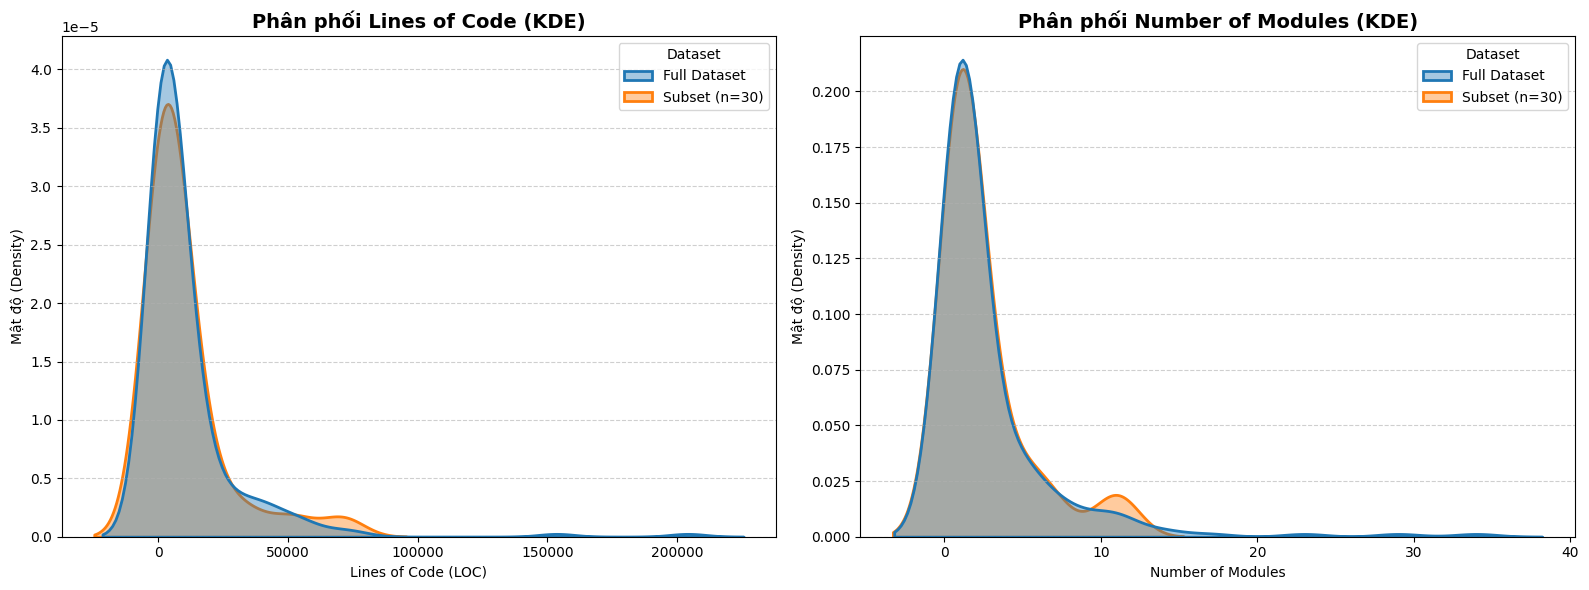

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_kde_comparison(full_df, subset_df, output_path=""):
    """
    Vẽ biểu đồ KDE so sánh phân phối giữa Full Dataset và Subset.
    """
    # Gộp dữ liệu để dễ dùng hue trong seaborn
    full_df_temp = full_df[['loc', 'modules']].copy()
    full_df_temp['Dataset'] = 'Full Dataset'
    
    subset_df_temp = subset_df[['loc', 'modules']].copy()
    subset_df_temp['Dataset'] = f'Subset (n={len(subset_df)})'
    
    combined_df = pd.concat([full_df_temp, subset_df_temp])
    
    # Khởi tạo Figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Vẽ KDE cho Lines of Code (LOC)
    sns.kdeplot(
        data=combined_df, x='loc', hue='Dataset', 
        fill=True, alpha=0.4, linewidth=2, common_norm=False, ax=axes[0]
    )
    axes[0].set_title('Phân phối Lines of Code (KDE)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Lines of Code (LOC)')
    axes[0].set_ylabel('Mật độ (Density)')
    axes[0].grid(axis='y', linestyle='--', alpha=0.6)
    
    # 2. Vẽ KDE cho Number of Modules
    sns.kdeplot(
        data=combined_df, x='modules', hue='Dataset', 
        fill=True, alpha=0.4, linewidth=2, common_norm=False, ax=axes[1]
    )
    axes[1].set_title('Phân phối Number of Modules (KDE)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Number of Modules')
    axes[1].set_ylabel('Mật độ (Density)')
    axes[1].grid(axis='y', linestyle='--', alpha=0.6)
    
    # Căn chỉnh và xuất file
    plt.tight_layout()
    if output_path != "":
        plt.savefig(output_path, dpi=300)
    plt.show()

# --- CÁCH SỬ DỤNG ---
# Giả sử bạn đã chạy hàm lấy mẫu:
my_subset = greedy_wasserstein_sampling(df, n_samples=30, iterations=2000)

# Gọi hàm vẽ biểu đồ:
plot_kde_comparison(df, my_subset)

In [4]:
my_subset

,repo_name,loc,modules
154,merapar/graphql-spring-boot-starter,985,2
221,wso2/balana,51701,5
137,jparsec/jparsec,16033,3
223,youngmonkeys/ezyfox-server,24867,6
180,rmuller/infomas-asl,1448,1
181,rometools/rome,71007,4
151,mboudreau/Alternator,35099,1
69,amazon-archives/aws-apigateway-importer,0,1
191,spotify/apollo,15370,11
100,davidmoten/rxjava-extras,12237,1
